# <center> FTIR Image: Semantic Segmentation of Breast Tissue Biopsy Cores using U-Net </center>

## Google Colab / GPU setup

In [1]:
# Detect Colab if present
try:
    from google.colab import drive
    COLAB = True
    print('Note: using Google Colab')
except:
    print('Note: not using Google Colab')
    COLAB = False

# Use GPU or MPS (Apple) if available
import torch
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Note: not using Google Colab
Using device: mps


## FTIR Core Images Dataset

In [2]:
import numpy as np
import os
from PIL import Image, ImageOps
from torch.utils.data import Dataset, DataLoader


class FTIRDataset(Dataset):
    # Initialise dataset directories and list of image files
    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = [img for img in os.listdir(image_dir) if img.lower().endswith('.tif')]

    # Return total number of images in the dataset
    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx].replace('.tif', '.png'))
        image = Image.open(img_path).convert('L')
        mask = Image.open(mask_path).convert('RGB')

        image = np.array(self._pad_image(image, target_size=(256, 256), is_mask=False))
        mask = np.array(self._pad_image(mask, target_size=(256, 256), is_mask=True))

        mask = self._process_mask(mask)

        return image, mask

    def _process_mask(self, mask):
        label_mask = np.zeros((mask.shape[0], mask.shape[1]), dtype=np.int64) # black: background/unlabelled
        label_mask[np.all(mask == [255, 0, 0], axis=-1)] = 1 # red: malignant epithelium
        label_mask[np.all(mask == [165, 55, 156], axis=-1)] = 2 # purple: malignant stroma
        label_mask[np.all(mask == [103, 193, 66], axis=-1)] = 3 # green: non-malignant epithelium
        label_mask[np.all(mask == [243, 143, 53], axis=-1)] = 4 # amber/orange: non-malignant stroma
        
        return label_mask

    def _pad_image(self, image, target_size, is_mask):
        delta_width = target_size[0] - image.width
        delta_height = target_size[1] - image.height
        padding = (delta_width // 2, delta_height // 2, delta_width - (delta_width // 2), delta_height - (delta_height // 2))
        padding_value = 0 if not is_mask else (0, 0, 0)  
        return ImageOps.expand(image, border=padding, fill=padding_value)

train_img_dir = 'dataset/FTIR_core_train_images/'
train_mask_dir = 'dataset/ftir_core_train_masks1'
test_img_dir = 'dataset/FTIR_core_test_images/'
test_mask_dir = 'dataset/ftir_core_test_masks1/'

# Training set (32 malignant cores, 8 non-malignant cores)
train_set = FTIRDataset(image_dir=train_img_dir, mask_dir=train_mask_dir)

# Independent test set (8 malignant cores, 2 non-malignant cores)
test_set = FTIRDataset(image_dir=test_img_dir, mask_dir=test_mask_dir)

print(f'Number of training images: {len(train_set)}')
print(f'Number of testing images: {len(test_set)}')

Number of training images: 40
Number of testing images: 10


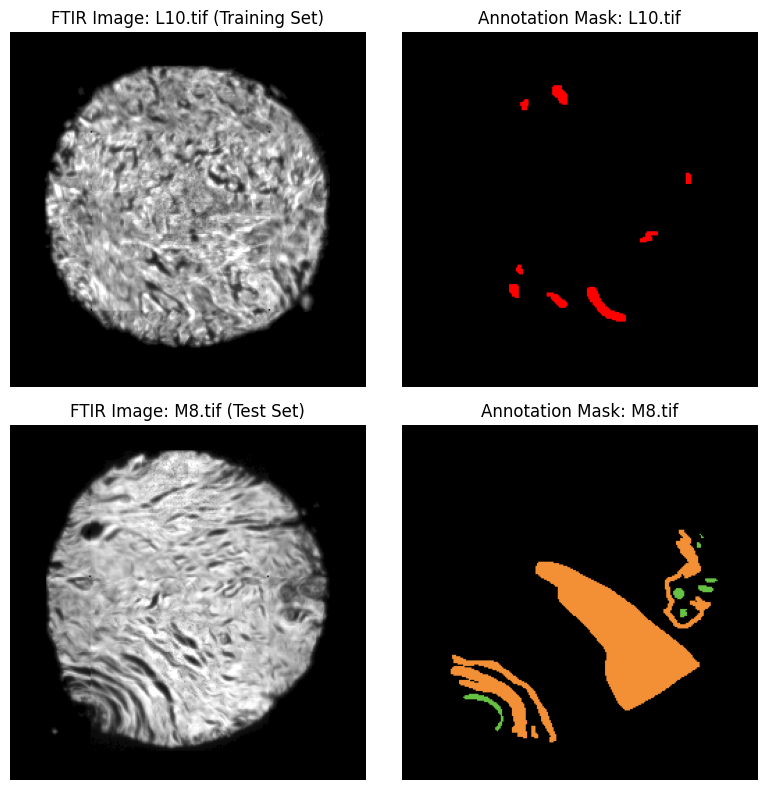

In [3]:
import matplotlib.pyplot as plt
import random


def display_image_and_mask(ax_image, ax_mask, dataset, index, set_title):
    image, mask = dataset[index]
    core_name = dataset.images[index]
    
    colourmap = np.array([
        [0, 0, 0],        # background/unlabelled (black)
        [255, 0, 0],      # class 1 (red)
        [165, 55, 156],   # class 2 (purple)
        [103, 193, 66],   # class 3 (green)
        [243, 143, 53]    # class 4 (amber)
    ], dtype=np.uint8)
    
    coloured_mask = colourmap[mask]

    ax_image.imshow(image, cmap='gray')
    ax_image.set_title(f'FTIR Image: {core_name} ({set_title} Set)')
    ax_image.axis('off')

    ax_mask.imshow(coloured_mask)
    ax_mask.set_title(f'Annotation Mask: {core_name}')
    ax_mask.axis('off')

# Display random FTIR image & corresponding mask from training set and independent test set
fig, ax = plt.subplots(2, 2, figsize=(8, 8))
train_idx = random.randint(0, len(train_set) - 1)
test_idx = random.randint(0, len(test_set) - 1)
display_image_and_mask(ax[0, 0], ax[0, 1], train_set, train_idx, 'Training')
display_image_and_mask(ax[1, 0], ax[1, 1], test_set, test_idx, 'Test')

plt.tight_layout()
plt.show()


Training set class distribution: {0: 2448437, 1: 87455, 2: 20943, 3: 9702, 4: 54903}

Training set percentages:
   Background: 93.40%
   Malignant Epithelium: 3.34%
   Malignant Stroma: 0.80%
   Non-malignant Epithelium: 0.37%
   Non-malignant Stroma: 2.09%

Test set class distribution: {0: 630161, 1: 4748, 2: 5642, 3: 750, 4: 14059}

Test set percentages:
   Background: 96.15%
   Malignant Epithelium: 0.72%
   Malignant Stroma: 0.86%
   Non-malignant Epithelium: 0.11%
   Non-malignant Stroma: 2.15%


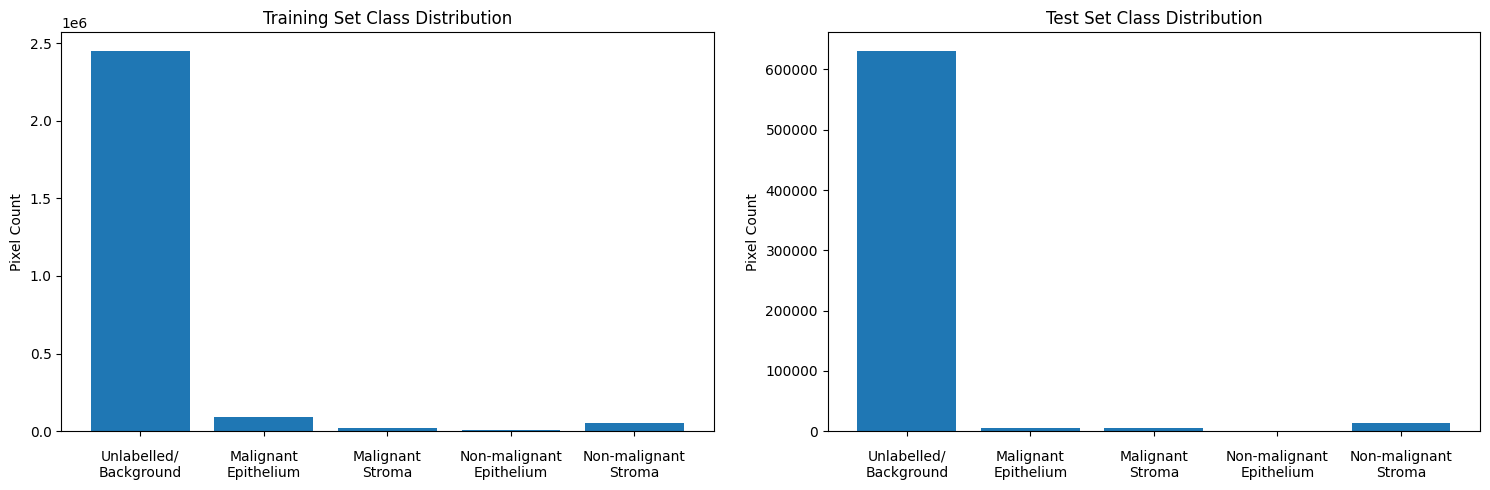

In [4]:
def get_class_distribution(dataset, set_title):
    class_counts = {0: 0, 1: 0, 2: 0, 3: 0, 4: 0}
    for _, mask in dataset:
        unique, counts = np.unique(mask, return_counts=True)
        for u, c in zip(unique, counts):
            class_counts[u] += c
    print(f'\n{set_title} set class distribution: {class_counts}')

    total = sum(class_counts.values())
    percentages = {k: (v / total) * 100 for k, v in class_counts.items()}
    print(f'\n{set_title} set percentages:')
    print(f'   Background: {percentages[0]:.2f}%')
    print(f'   Malignant Epithelium: {percentages[1]:.2f}%')
    print(f'   Malignant Stroma: {percentages[2]:.2f}%')
    print(f'   Non-malignant Epithelium: {percentages[3]:.2f}%')
    print(f'   Non-malignant Stroma: {percentages[4]:.2f}%')

    return class_counts


# Calculate class distributions for training & test sets
train_class_distribution = get_class_distribution(train_set, 'Training')
test_class_distribution = get_class_distribution(test_set, 'Test')

# Plot class distribution
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
class_labels = ['Unlabelled/\nBackground', 'Malignant\nEpithelium', 'Malignant\nStroma', 'Non-malignant\nEpithelium', 'Non-malignant\nStroma']

ax[0].bar(class_labels, [train_class_distribution[i] for i in range(5)])
ax[0].set_title('Training Set Class Distribution')
ax[0].set_ylabel('Pixel Count')
ax[0].tick_params(axis='x', pad=10, labelsize=10)

ax[1].bar(class_labels, [test_class_distribution[i] for i in range(5)])
ax[1].set_title('Test Set Class Distribution')
ax[1].set_ylabel('Pixel Count')
ax[1].tick_params(axis='x', pad=10, labelsize=10)

plt.tight_layout()
plt.subplots_adjust(wspace=0.175) 
plt.show()

## Augmentations

In [5]:
import albumentations as A
import cv2
from albumentations.pytorch import ToTensorV2


class WrapperDataset(Dataset):
    def __init__(self, base_dataset, transform=None):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, mask = self.base_dataset[idx]

        image = np.array(image)
        mask = np.array(mask)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image, mask

# Augment training set images & masks
def get_training_augmentation():
    train_transform = A.Compose([
        A.Resize(IMG_HEIGHT, IMG_WIDTH),
        A.HorizontalFlip(p=0.5), 
        A.VerticalFlip(p=0.5),   
        A.Rotate(limit=90, border_mode=cv2.BORDER_CONSTANT, value=0, p=0.5),  
        A.Normalize(mean=[0.5], std=[0.5]),
        ToTensorV2(),
    ])
    return train_transform

# No augmentations applied to test set images
def get_test_augmentation():
    val_transform = A.Compose([
        A.Resize(IMG_HEIGHT, IMG_WIDTH),
        A.Normalize(mean=[0.5], std=[0.5]),
        ToTensorV2(),
    ])
    return val_transform


IMG_HEIGHT = IMG_WIDTH = 256
BATCH_SIZE = 8
train_transform = get_training_augmentation()
test_transform = get_test_augmentation()

augmented_train_set = WrapperDataset(train_set, transform=train_transform)
augmented_train_loader = DataLoader(augmented_train_set, batch_size=BATCH_SIZE, shuffle=True)
test_set_wrap = WrapperDataset(test_set, transform=test_transform)
test_loader = DataLoader(test_set_wrap, batch_size=10, shuffle=False)

## Model Architecture, Hyperparameters and Training

In [6]:
from sklearn.utils.class_weight import compute_class_weight


# Compute class weights based on proportion of pixels in training set that belong to each class
labels = []
for _, mask in train_set:
    labels.extend(mask.ravel())

labels = np.array(labels)
unique_classes = np.unique(labels)
weights = compute_class_weight('balanced', classes=unique_classes, y=labels)

class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

print('Unique classes in training set masks:', unique_classes)
print('Computed class weights:', weights)

Unique classes in training set masks: [0 1 2 3 4]
Computed class weights: [ 0.21413171  5.99494597 25.03404479 54.03916718  9.54935067]


In [7]:
import torch.nn.functional as F
from segmentation_models_pytorch.losses import DiceLoss


# Combined Dice Loss and Focal Loss to account for severe class imbalance
class CombinedLoss(torch.nn.Module):
    def __init__(self, num_classes, alpha=None, gamma=2):
        super().__init__()
        self.num_classes = num_classes
        self.gamma = gamma

        if alpha is None:
            self.alpha = torch.ones(num_classes)
        else:
            self.alpha = alpha
        self.alpha = self.alpha.to(DEVICE)
        
        self.w_d = 1
        self.w_f = 1
        self.dice_loss = DiceLoss(mode='multiclass', from_logits=True)

    def forward(self, output, target):
        dice_loss = self.dice_loss(output, target)
        focal_loss = self.focal_loss(output, target)
        
        combined = self.w_d * dice_loss + self.w_f * focal_loss
        return combined

    def focal_loss(self, output, target):
        ce_loss = F.cross_entropy(output, target, reduction='none')
        pt = torch.exp(-ce_loss)
        target_one_hot = F.one_hot(target, num_classes=self.num_classes).float()
        alpha_t = (self.alpha * target_one_hot).sum(dim=-1)
        focal_loss = alpha_t * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

In [8]:
import segmentation_models_pytorch as smp
from torchinfo import summary


# U-Net model with Resnet34 backbone
def init_model(num_classes, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS):
    model = smp.Unet(
        encoder_name='resnet34',
        encoder_weights='imagenet',
        in_channels=IMG_CHANNELS,
        classes=num_classes, 
    )
    model.to(DEVICE)
    return model


num_classes = 5
IMG_CHANNELS = 1 # Grayscale FTIR images

learning_rate = 1e-4
model = init_model(num_classes, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)
optimiser = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = CombinedLoss(num_classes=num_classes, alpha=class_weights, gamma=2)

print('Model Summary:')
summary(model, input_size=(BATCH_SIZE, IMG_CHANNELS, IMG_HEIGHT, IMG_WIDTH))

Model Summary:


Layer (type:depth-idx)                        Output Shape              Param #
Unet                                          [8, 5, 256, 256]          --
├─ResNetEncoder: 1-1                          [8, 1, 256, 256]          --
│    └─Conv2d: 2-1                            [8, 64, 128, 128]         3,136
│    └─BatchNorm2d: 2-2                       [8, 64, 128, 128]         128
│    └─ReLU: 2-3                              [8, 64, 128, 128]         --
│    └─MaxPool2d: 2-4                         [8, 64, 64, 64]           --
│    └─Sequential: 2-5                        [8, 64, 64, 64]           --
│    │    └─BasicBlock: 3-1                   [8, 64, 64, 64]           73,984
│    │    └─BasicBlock: 3-2                   [8, 64, 64, 64]           73,984
│    │    └─BasicBlock: 3-3                   [8, 64, 64, 64]           73,984
│    └─Sequential: 2-6                        [8, 128, 32, 32]          --
│    │    └─BasicBlock: 3-4                   [8, 128, 32, 32]          230,144

In [9]:
model.to(DEVICE)

num_epochs = 400

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    correct_train = 0
    total_train = 0

    for images, masks in augmented_train_loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        masks = masks.squeeze(1)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, masks.long())
        #loss = combined_loss(outputs, masks.long())

        # Backward pass and optimisation
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

        total_train_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == masks).sum().item()
        total_train += masks.nelement()

    avg_train_loss = total_train_loss / len(augmented_train_loader)
    train_losses.append(avg_train_loss)
    train_accuracy = 100.0 * correct_train / total_train
    train_accuracies.append(train_accuracy)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'Epoch [{epoch + 1} / {num_epochs}]: Loss = {avg_train_loss:.4f}, Acc = {train_accuracy:.2f}')

Epoch [1 / 400]: Loss = 18.7893, Acc = 42.70
Epoch [10 / 400]: Loss = 13.3737, Acc = 55.74
Epoch [20 / 400]: Loss = 11.4989, Acc = 59.53
Epoch [30 / 400]: Loss = 10.9976, Acc = 61.82
Epoch [40 / 400]: Loss = 10.7148, Acc = 63.06
Epoch [50 / 400]: Loss = 10.2686, Acc = 66.26
Epoch [60 / 400]: Loss = 9.6887, Acc = 68.49
Epoch [70 / 400]: Loss = 9.3876, Acc = 68.77
Epoch [80 / 400]: Loss = 9.4591, Acc = 71.06
Epoch [90 / 400]: Loss = 9.2762, Acc = 73.22
Epoch [100 / 400]: Loss = 9.1868, Acc = 75.15
Epoch [110 / 400]: Loss = 8.9217, Acc = 77.31
Epoch [120 / 400]: Loss = 9.1810, Acc = 76.51
Epoch [130 / 400]: Loss = 12.7649, Acc = 78.56
Epoch [140 / 400]: Loss = 9.2766, Acc = 76.63
Epoch [150 / 400]: Loss = 9.0077, Acc = 78.33
Epoch [160 / 400]: Loss = 8.8477, Acc = 81.36
Epoch [170 / 400]: Loss = 9.3464, Acc = 80.30
Epoch [180 / 400]: Loss = 9.4284, Acc = 80.60
Epoch [190 / 400]: Loss = 8.8763, Acc = 82.86
Epoch [200 / 400]: Loss = 8.8746, Acc = 83.65
Epoch [210 / 400]: Loss = 8.5976, Acc 

## Results

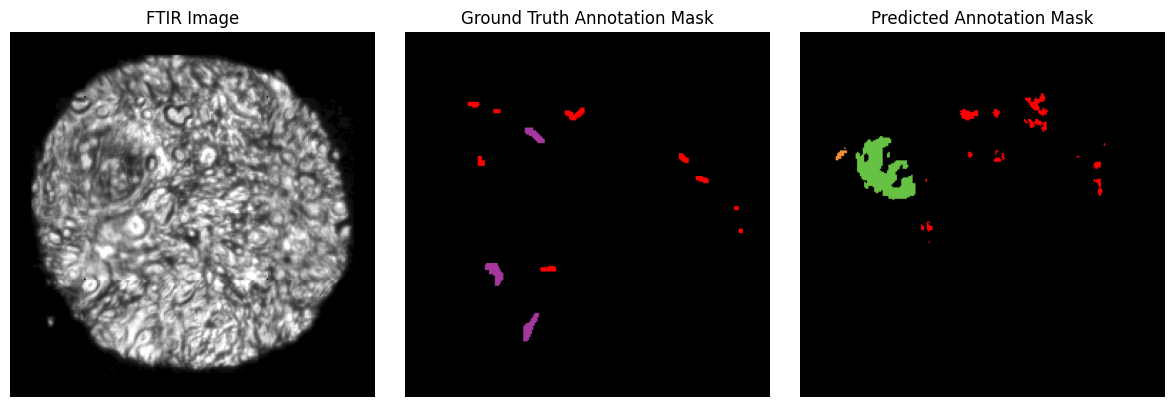

Image 1:
  Class 0: IoU = 0.9737, Dice = 0.9867
  Class 1: IoU = 0.1239, Dice = 0.2204
  Class 2: IoU = 0.0000, Dice = 0.0000
  Class 3: IoU = 0.0000, Dice = 0.0000
  Class 4: IoU = 0.0000, Dice = 0.0000
  Mean IoU = 0.2195, Mean Dice = 0.2414



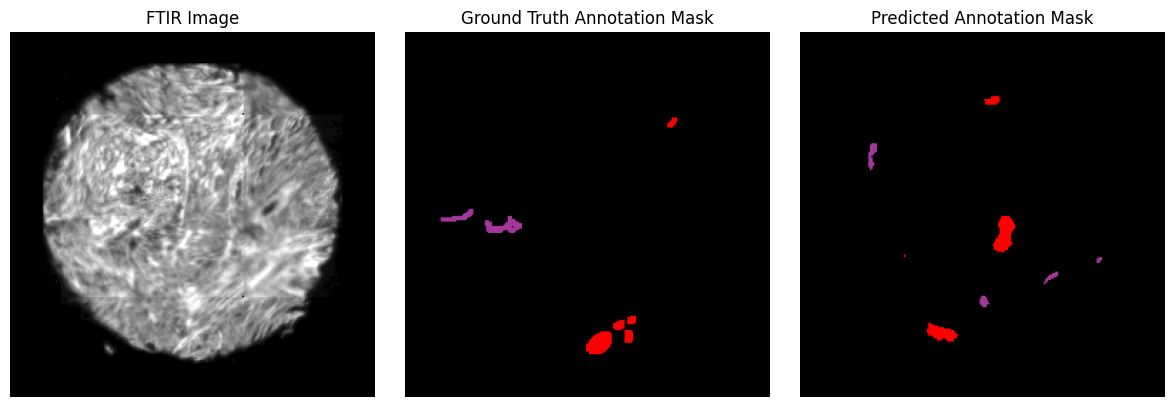

Image 2:
  Class 0: IoU = 0.9806, Dice = 0.9902
  Class 1: IoU = 0.0000, Dice = 0.0000
  Class 2: IoU = 0.0000, Dice = 0.0000
  Class 3: IoU = 0.0000, Dice = 0.0000
  Class 4: IoU = 0.0000, Dice = 0.0000
  Mean IoU = 0.1961, Mean Dice = 0.1980



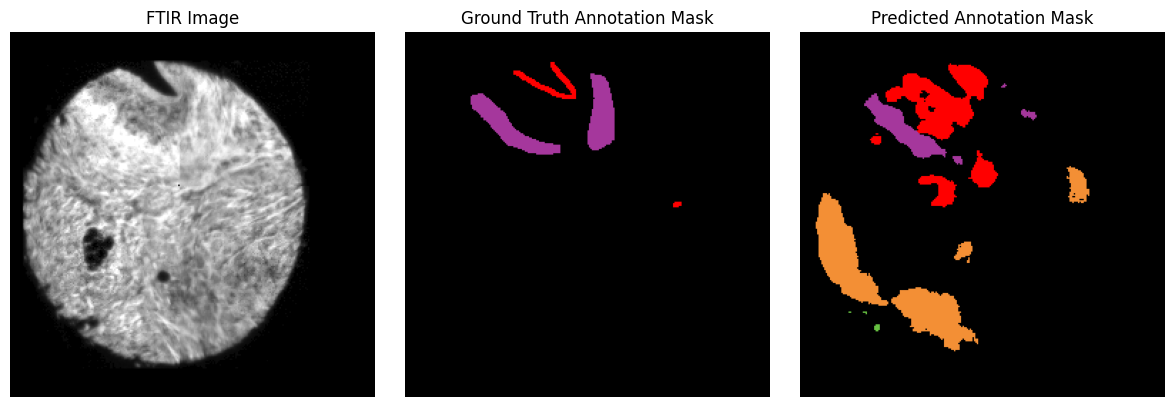

Image 3:
  Class 0: IoU = 0.8921, Dice = 0.9430
  Class 1: IoU = 0.0811, Dice = 0.1501
  Class 2: IoU = 0.3915, Dice = 0.5627
  Class 3: IoU = 0.0000, Dice = 0.0000
  Class 4: IoU = 0.0000, Dice = 0.0000
  Mean IoU = 0.2729, Mean Dice = 0.3311



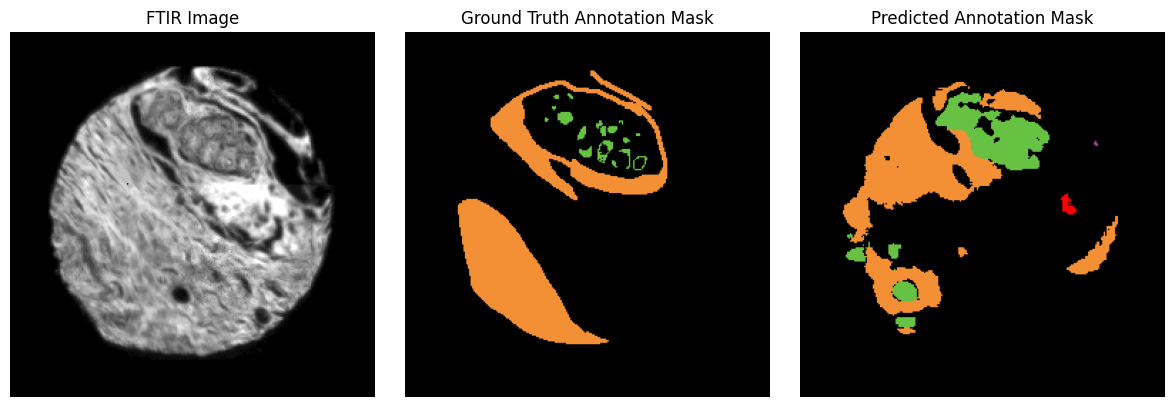

Image 4:
  Class 0: IoU = 0.8506, Dice = 0.9192
  Class 1: IoU = 0.0000, Dice = 0.0000
  Class 2: IoU = 0.0000, Dice = 0.0000
  Class 3: IoU = 0.1655, Dice = 0.2840
  Class 4: IoU = 0.2917, Dice = 0.4517
  Mean IoU = 0.2616, Mean Dice = 0.3310



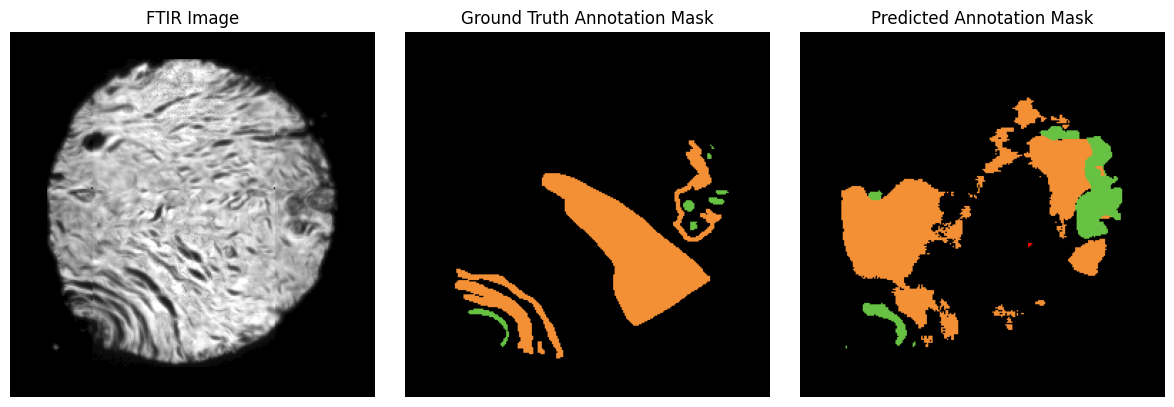

Image 5:
  Class 0: IoU = 0.7885, Dice = 0.8818
  Class 1: IoU = 0.0000, Dice = 0.0000
  Class 2: IoU = 0.0000, Dice = 0.0000
  Class 3: IoU = 0.1551, Dice = 0.2685
  Class 4: IoU = 0.0766, Dice = 0.1424
  Mean IoU = 0.2041, Mean Dice = 0.2585



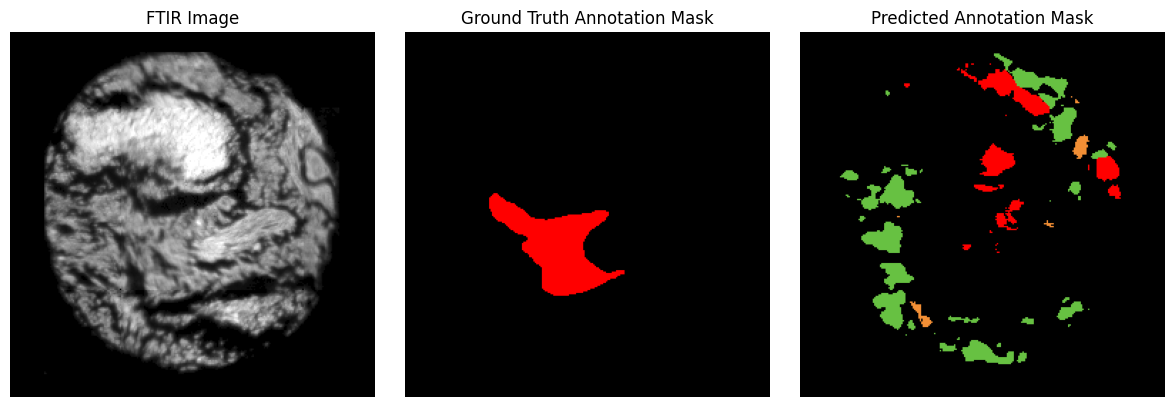

Image 6:
  Class 0: IoU = 0.8817, Dice = 0.9371
  Class 1: IoU = 0.0098, Dice = 0.0193
  Class 2: IoU = 0.0000, Dice = 0.0000
  Class 3: IoU = 0.0000, Dice = 0.0000
  Class 4: IoU = 0.0000, Dice = 0.0000
  Mean IoU = 0.1783, Mean Dice = 0.1913



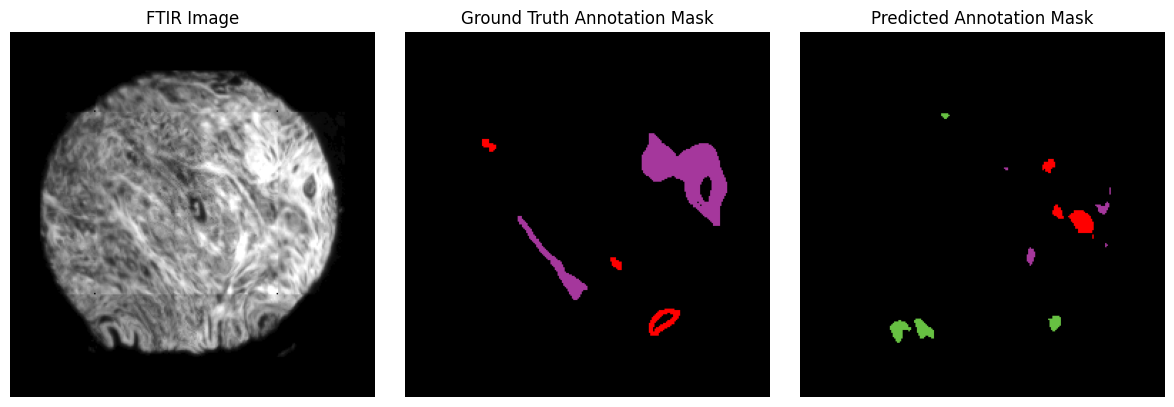

Image 7:
  Class 0: IoU = 0.9533, Dice = 0.9761
  Class 1: IoU = 0.0000, Dice = 0.0000
  Class 2: IoU = 0.0219, Dice = 0.0428
  Class 3: IoU = 0.0000, Dice = 0.0000
  Class 4: IoU = 0.0000, Dice = 0.0000
  Mean IoU = 0.1950, Mean Dice = 0.2038



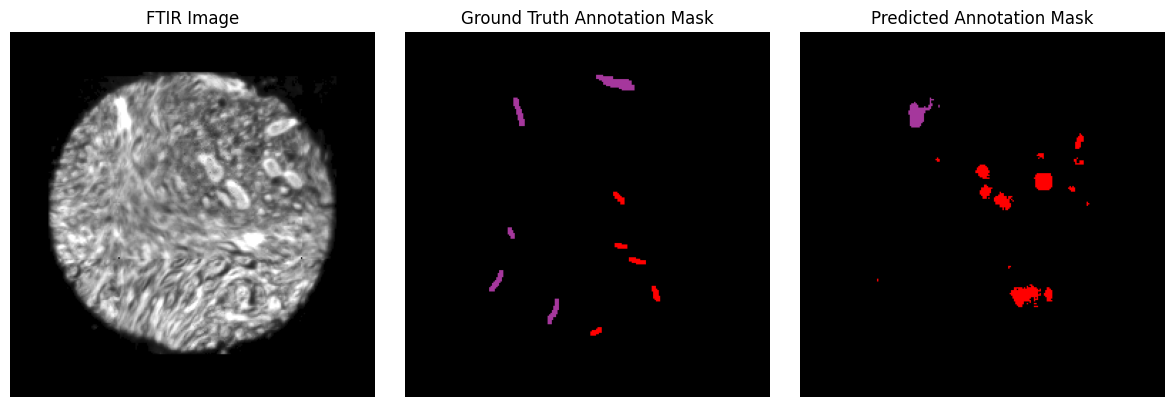

Image 8:
  Class 0: IoU = 0.9801, Dice = 0.9900
  Class 1: IoU = 0.0346, Dice = 0.0668
  Class 2: IoU = 0.1200, Dice = 0.2143
  Class 3: IoU = 0.0000, Dice = 0.0000
  Class 4: IoU = 0.0000, Dice = 0.0000
  Mean IoU = 0.2269, Mean Dice = 0.2542



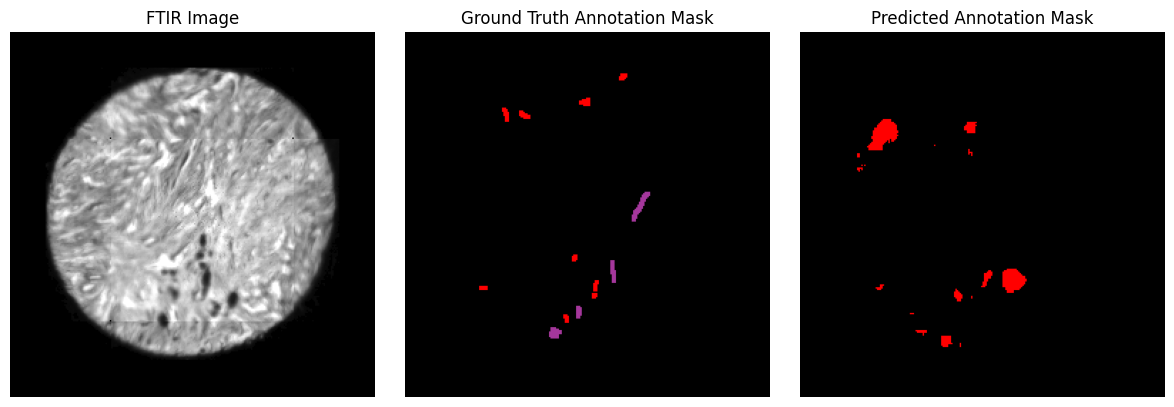

Image 9:
  Class 0: IoU = 0.9829, Dice = 0.9914
  Class 1: IoU = 0.0102, Dice = 0.0203
  Class 2: IoU = 0.0000, Dice = 0.0000
  Class 3: IoU = 0.0000, Dice = 0.0000
  Class 4: IoU = 0.0000, Dice = 0.0000
  Mean IoU = 0.1986, Mean Dice = 0.2023



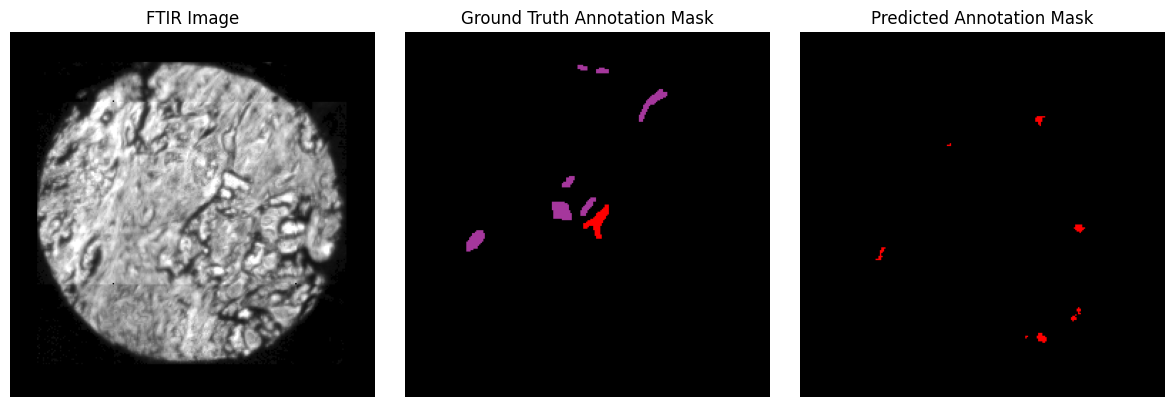

Image 10:
  Class 0: IoU = 0.9868, Dice = 0.9933
  Class 1: IoU = 0.0000, Dice = 0.0000
  Class 2: IoU = 0.0000, Dice = 0.0000
  Class 3: IoU = 0.0000, Dice = 0.0000
  Class 4: IoU = 0.0000, Dice = 0.0000
  Mean IoU = 0.1974, Mean Dice = 0.1987



In [15]:
def calculate_metrics(true_mask, pred_mask, num_classes):
    iou_scores = []
    dice_scores = []
    for class_id in range(num_classes):
        true_class = (true_mask == class_id).astype(np.uint8)
        pred_class = (pred_mask == class_id).astype(np.uint8)
        
        intersection = np.logical_and(true_class, pred_class).sum()
        union = np.logical_or(true_class, pred_class).sum()
        
        iou = intersection / union if union > 0 else 0
        iou_scores.append(iou)
        
        dice = (2 * intersection) / (true_class.sum() + pred_class.sum()) if (true_class.sum() + pred_class.sum()) > 0 else 0
        dice_scores.append(dice)
    
    return iou_scores, dice_scores

def class_to_colour(mask):
    colourmap = np.array([
        [0, 0, 0],        # background/unlabelled regions (black)
        [255, 0, 0],      # Malignant epithelium (red)
        [165, 55, 156],   # Malignant stroma (purple)
        [103, 193, 66],   # Non-malignant epithelium (green)
        [243, 143, 53]    # Non-malignant stroma (amber)
    ], dtype=np.uint8)
    mask = mask.astype(np.int32)  
    return colourmap[mask]


# Predict annotation masks for all 10 images in independent test set
# Classes:
#   0: background/unlabelled; 1: malignant epithelium; 2: malignant stroma; 3: non-malignant epitheliuml 4: non-malignant stroma
model.eval()
all_true_masks = []
all_pred_masks = []
num_classes = 5

with torch.no_grad():
    for i, (images, true_masks) in enumerate(test_loader):
        images = images.to(DEVICE).float()
        true_masks = true_masks.to(DEVICE)
        preds = model(images)
        preds = torch.argmax(preds, dim=1)

        images = images.cpu().numpy()
        true_masks = true_masks.cpu().numpy()
        preds = preds.cpu().numpy()

        all_true_masks.extend(true_masks)
        all_pred_masks.extend(preds)

        batch_size = images.shape[0]
        for idx in range(batch_size):
            fig, ax = plt.subplots(1, 3, figsize=(12, 4))  

            # Input Image
            img = images[idx][0] 
            img = (img - img.min()) / (img.max() - img.min()) 
            ax[0].imshow(img, cmap='gray')
            ax[0].set_title('FTIR Image')
            ax[0].axis('off')

            # True Mask
            true_coloured_mask = class_to_colour(true_masks[idx])
            ax[1].imshow(true_coloured_mask)
            ax[1].set_title('Ground Truth Annotation Mask')
            ax[1].axis('off')

            # Predicted Mask
            predicted_coloured_mask = class_to_colour(preds[idx])
            ax[2].imshow(predicted_coloured_mask)
            ax[2].set_title('Predicted Annotation Mask')
            ax[2].axis('off')

            plt.tight_layout()
            plt.show()

            # Calculate and display metrics for this image
            iou_scores, dice_scores = calculate_metrics(true_masks[idx], preds[idx], num_classes)
            print(f'Image {i * batch_size + idx + 1}:')
            for class_id in range(num_classes):
                print(f'  Class {class_id}: IoU = {iou_scores[class_id]:.4f}, Dice = {dice_scores[class_id]:.4f}')
            print(f'  Mean IoU = {np.mean(iou_scores):.4f}, Mean Dice = {np.mean(dice_scores):.4f}\n')

In [16]:
# Summary metrics
all_true_masks = np.array(all_true_masks)
all_pred_masks = np.array(all_pred_masks)
overall_iou_scores, overall_dice_scores = calculate_metrics(all_true_masks, all_pred_masks, num_classes)

print('Overall Metrics:')
print('----------------')
for class_id in range(num_classes):
    print(f'Class {class_id}: IoU = {overall_iou_scores[class_id]:.4f}, Dice = {overall_dice_scores[class_id]:.4f}')
print(f'---\nMean IoU = {np.mean(overall_iou_scores):.4f}, Mean Dice = {np.mean(overall_dice_scores):.4f}')

Overall Metrics:
----------------
Class 0: IoU = 0.9279, Dice = 0.9626
Class 1: IoU = 0.0321, Dice = 0.0621
Class 2: IoU = 0.1326, Dice = 0.2342
Class 3: IoU = 0.0789, Dice = 0.1462
Class 4: IoU = 0.1488, Dice = 0.2590
---
Mean IoU = 0.2641, Mean Dice = 0.3328


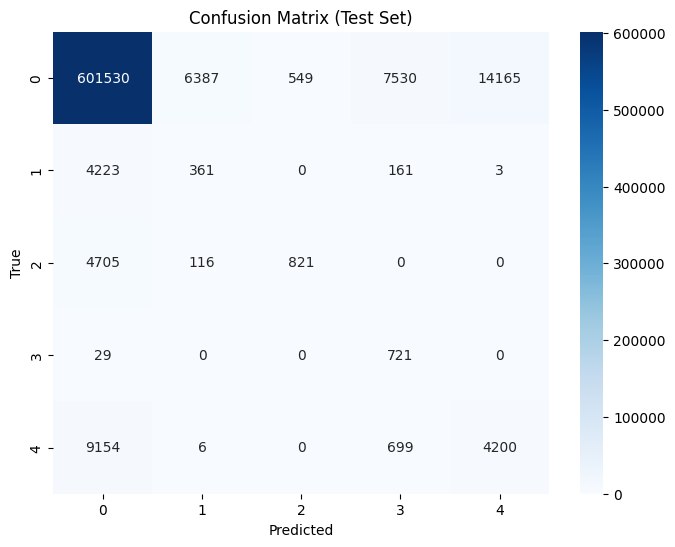

In [17]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrix for independent test set (classes 0 - 4)
cm = confusion_matrix(all_true_masks.flatten(), all_pred_masks.flatten(), labels=range(num_classes))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()